### Imports

In [1]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from reeb_utils import do_reeb_for_start_end, do_reeb_for_explore_node, plot_treeb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

### Load data

In [129]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

# # Calculate min path dist; first set v high for the wrong people
# # Note: there's definitely a smarter way to do this in pandas
# test_df["fake_dist"] = test_df["trajs"].apply(len)
# test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

# test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

### Compute treebs

In [130]:
## BY PATH
treebs = []
accs = []
path_dists = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    G = do_reeb_for_start_end(test_df, start_node, end_node, 0, use_turns=False) # 0 means all quartiles
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    treebs.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    # print(group["Path.Distance"])
    # path_dists.append(group["Path.Distance"])

## BY QUARTILE
# treebs = []
# qs = []
# accs_by_q = []
# for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
#     for i in range(1,5):
#         G = do_reeb_for_start_end(test_df, start_node, end_node, i, use_turns=False)
#         new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
#         treebs.append(new_G)
#         qs.append(i)
#         accs_by_q.append(group[group["quartile"]==i]["path_mean_acc_by_Q"].iloc[0])

### Tree features fn

In [10]:
def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Number of Edges
    num_edges = graph.number_of_edges()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Average Node Degree
    avg_degree = np.mean([degree for node, degree in graph.degree()])
    
    # Diameter
    diameter = nx.diameter(graph)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Average Path Length
    avg_path_length = nx.average_shortest_path_length(graph)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Clustering Coefficient
    clustering_coeffs = nx.clustering(graph)
    avg_clustering_coeff = np.mean(list(clustering_coeffs.values()))
    
    # Put all features in a list
    features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        avg_clustering_coeff
    ]
    
    return features

### Do graph embeddings

https://karateclub.readthedocs.io/en/latest/modules/root.html#whole-graph-embedding

* **Graph2Vec:** An implementation of “Graph2Vec” from the MLGWorkshop ‘17 paper “Graph2Vec: Learning Distributed Representations of Graphs”. The procedure creates Weisfeiler-Lehman tree features for nodes in graphs. Using these features a document (graph) - feature co-occurrence matrix is decomposed in order to generate representations for the graphs.

In [196]:
model = kc.Graph2Vec(dimensions=16)
model.fit(treebs)

embedding_features = model.get_embedding()

features = np.array([extract_tree_features(treeb, 0) for treeb in treebs])

### Visualise embeddings in 2D

[0.80982774 0.01030033]


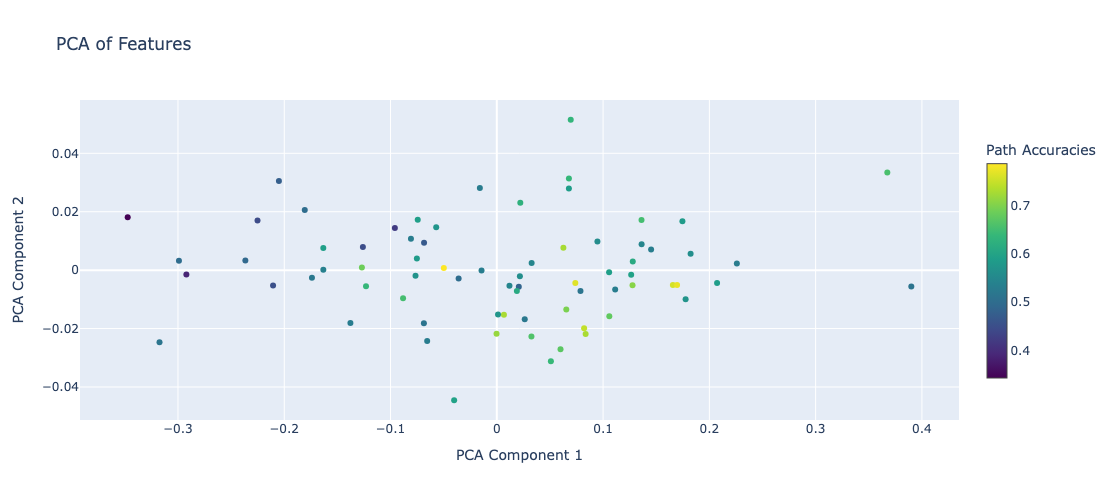

In [170]:
# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(embedding_features)
# reduced_features = pca.fit_transform(features)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)

# Plot the clusters with Plotly to have interactive
fig = go.Figure()

# Scatter plot for 'Trees by Quartile'
fig.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=accs, colorscale='Viridis', showscale=True, 
                colorbar=dict(title="Path Accuracies", thickness=20, x=30, len=0.8)),
    name='Trees by Quartile',
))

# Update layout
fig.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title_text="Path Accuracies",
    height=500,
    width=500
)

fig.show()

# print(abs( pca.components_ ))

## Regressions

#### Util fns

In [277]:
from plotly.subplots import make_subplots

def run_evaluate_regression(X, y, feature_str=""):
    # Initialize and fit the linear regression model
    model = LinearRegression()
    
    ## K-fold cross validation
    
    # Define the number of folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store RMSE for each fold
    rmse_list = []
    
    # Perform the cross-validation
    for train_index, test_index in kf.split(X):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Append RMSE to the list
        rmse_list.append(rmse)
    
    # Convert RMSE list to a numpy array for statistical calculations
    rmse_array = np.array(rmse_list)
    
    mean_rmse = np.mean(rmse_array)
    std_rmse = np.std(rmse_array)
    
    print(f"Mean RMSE: {mean_rmse}")
    print(f"Standard Deviation of RMSE: {std_rmse}")
    
    # Get the regression coefficient and intercept
    slope = model.coef_
    intercept = model.intercept_
    
    print(f"Linear Regression Coefficients:", slope)
    print(feature_str)
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {model.score(X, y):.2f}")

    print(X.shape)
    print(y.shape)

    # Identify top 3 most important features based on absolute value of coefficients
    top_features_indices = np.argsort(np.abs(slope))[-3:]  # Indices of the top 3 features
    top_features_names = np.array(feature_str.split(","))[top_features_indices]   # Names of the top 3 features
    
    # Create subplots with 3 plots (one for each top feature)
    fig = make_subplots(rows=1, cols=3, subplot_titles=top_features_names)
    
    # Plot each feature against the true y values in separate subplots
    j = 0
    for i in top_features_indices:
        feature_name = np.array(feature_str.split(","))[i]

        print(X[i].shape)
        # Scatter plot: feature vs actual y
        fig.add_trace(go.Scatter(x=X[:,i], y=y, mode='markers', name=f'{feature_name} vs y'),
                      row=1, col=j+1)

        feature_model = LinearRegression()
        feature_X = X[:,i:i+1] 
        feature_model.fit(feature_X, y)
        
        # Plot regression line: feature vs predicted y (y_pred)
        # Create values for the best-fit line
        feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
        feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

        fig.add_trace(go.Scatter(x=feature_x_range, y=feature_y_pred, mode='lines', name=f'{feature_name} regression line'),
                      row=1, col=j+1)
        j+=1
    
    # Update layout to make the plot visually appealing
    fig.update_layout(title_text="Top 3 Features vs Target Variable", height=400, width=1200)
    
    # Show plot
    fig.show()

def run_evaluate_knn_regression(X, y, distance_fn, k=5):

    # Initialize and fit the linear regression model
    model = KNNRegressor(k=k, distance_func=distance_fn)
    
    ## K-fold cross validation
    
    # Define the number of folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store RMSE for each fold
    rmse_list = []
    
    # Perform the cross-validation
    for train_index, test_index in kf.split(X):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Append RMSE to the list
        rmse_list.append(rmse)
    
    # Convert RMSE list to a numpy array for statistical calculations
    rmse_array = np.array(rmse_list)
    
    mean_rmse = np.mean(rmse_array)
    std_rmse = np.std(rmse_array)
    
    print(f"Mean RMSE: {mean_rmse}")
    print(f"Standard Deviation of RMSE: {std_rmse}")


### Tree features

Mean RMSE: 0.0741494532122698
Standard Deviation of RMSE: 0.009962495858788946
Linear Regression Coefficients: [-6.69680214e-03 -6.69680214e-03 -6.27289830e-04  2.26156291e+00
  7.93256352e-03  5.96847300e-03  2.56743471e-03  2.26156291e+00
  0.00000000e+00]
tree_features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        avg_clustering_coeff
    ]
Intercept: -7.89
R-squared: 0.46
(72, 9)
(72,)
(9,)
(9,)
(9,)


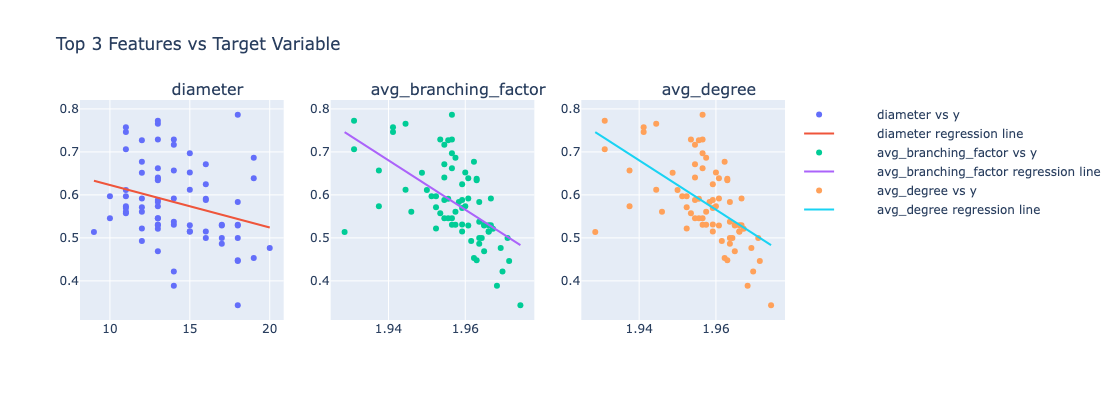

In [235]:
X, y = features, np.array(accs)
tree_feature_str = """tree_features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        avg_clustering_coeff
    ]"""
run_evaluate_regression(X, y, feature_str=tree_feature_str)

### Embeddings

Mean RMSE: 0.08625211949463504
Standard Deviation of RMSE: 0.015422198949073514
Linear Regression Coefficients: [-0.31560323  0.1259759 ]

        pca1_graph2vec (16d),
        pca2_graph2vec (16d)
    ]
Intercept: 0.58
R-squared: 0.21
(72, 2)
(72,)
(2,)
(2,)


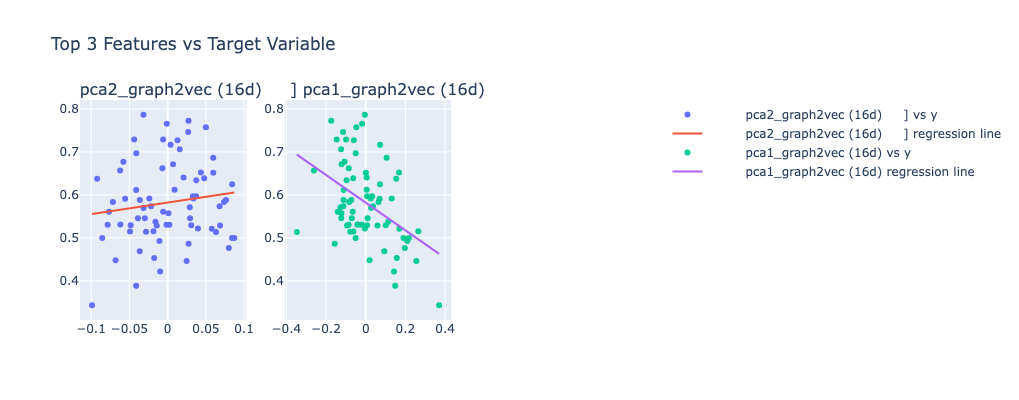

In [319]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(embedding_features)

X, y = reduced_features, np.array(accs)
embedding_feature_str = """
        pca1_graph2vec (16d),
        pca2_graph2vec (16d)
    ]"""
run_evaluate_regression(X, y, feature_str=embedding_feature_str)

### Flow Tree shapes

In [241]:
all_flow_trees = treebs

max_num_nodes = max(all_flow_trees, key=lambda x: x.number_of_nodes()).number_of_nodes()

# convert Flow Trees to padded adjacency matrices
padded_adj_mats = []
for ft in all_flow_trees:
    adj_mat = nx.adjacency_matrix(ft).todense()

    amt_to_pad = max_num_nodes - ft.number_of_nodes()
    padded_adj_mat = np.pad(adj_mat, pad_width=(0, amt_to_pad))

    padded_adj_mats.append(padded_adj_mat)

padded_adj_mats = np.array(padded_adj_mats)

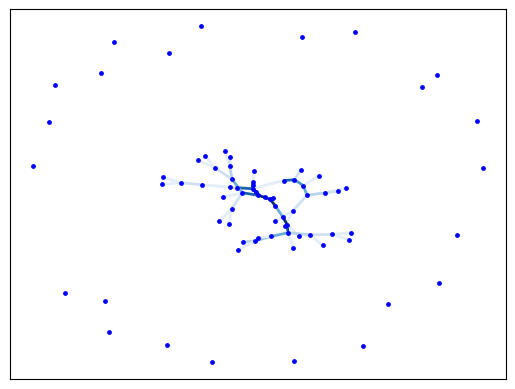

In [242]:
## STOLEN FROM GEOMSTATS DEMO
##  https://github.com/geomstats/geomstats/blob/main/notebooks/20_real_world_applications__graph_space.ipynb
import matplotlib.pyplot as plt
import networkx as nx

import geomstats.backend as gs
import geomstats.datasets.utils as data_utils
from geomstats.geometry.stratified.graph_space import GraphSpace
from geomstats.learning.aac import AAC

gs.random.seed(2020)

mammals_obs = nx.from_numpy_array(padded_adj_mats[5])
pos = nx.kamada_kawai_layout(mammals_obs)
edges, weights = zip(*nx.get_edge_attributes(mammals_obs, "weight").items())

pos = nx.spring_layout(mammals_obs)
nx.draw_networkx_nodes(mammals_obs, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    mammals_obs,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

## normal to have all the floating nodes; this is what happens when you are padded

In [243]:
total_space = GraphSpace(n_nodes=padded_adj_mats.shape[1])
total_space.equip_with_group_action()
total_space.equip_with_quotient()

aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=100)
aac_fm.fit(padded_adj_mats)

_AACFrechetMean(max_iter=100,
                space=<geomstats.geometry.stratified.graph_space.GraphSpace object at 0x170f209d0>,
                total_space_estimator_kwargs={})

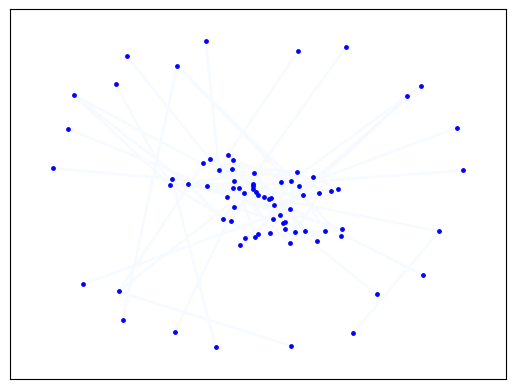

In [244]:
total_flow_trees_fm_mst = nx.minimum_spanning_tree(nx.from_numpy_array(aac_fm.estimate_))
edges, weights = zip(*nx.get_edge_attributes(total_flow_trees_fm_mst, "weight").items())

nx.draw_networkx_nodes(total_flow_trees_fm_mst, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    total_flow_trees_fm_mst,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

In [245]:
graph_space = total_space.quotient
graph_space

point_a, point_b, point_c = padded_adj_mats[0], padded_adj_mats[1], padded_adj_mats[-1]

dist_total = total_space.metric.dist(point_a, point_b)
dist_quotient = graph_space.metric.dist(point_a, point_b)

print(f"dist quotient <= dist total:\n{dist_quotient} <= {dist_total}")

print("dist a to c", graph_space.metric.dist(point_a, point_c))

dist quotient <= dist total:
71.07742257566744 <= 84.94704232638121
dist a to c 72.42927584892728


#### Have to do knn regression
because I don't have absolute values, just a distance function

In [260]:
import numpy as np
from collections import Counter

class KNNRegressor:
    def __init__(self, k, distance_func):
        self.k = k  # Number of nearest neighbors
        self.distance_func = distance_func  # Custom distance function

    def fit(self, X_train, y_train):
        """
        Store the training data.
        :param X_train: Training features, shape (n_samples, n_features)
        :param y_train: Training labels (target values), shape (n_samples,)
        """
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        """
        Predict the target values for the test data.
        :param X_test: Test features, shape (n_samples, n_features)
        :return: Predicted target values, shape (n_samples,)
        """
        predictions = []
        for x_test in X_test:
            # Calculate the distances between the test point and all training points
            distances = [self.distance_func(x_test, x_train) for x_train in self.X_train]
            # Get the indices of the k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            # Get the target values of the k nearest neighbors
            k_nearest_values = self.y_train[k_indices]
            # Predict by averaging the k nearest target values
            predictions.append(np.mean(k_nearest_values))
        return np.array(predictions)

def shape_dist(p1, p2):
    return graph_space.metric.dist(p1, p2)
    
def euclid_dist(p1, p2):
    return np.linalg.norm(p1-p2)

### Run all knn regressions

In [317]:
y = np.array(accs)

print("Baseline:")
run_evaluate_knn_regression(np.array(baseline_features), y, euclid_dist, k=5)

print("Heatmap:") 
run_evaluate_knn_regression(heatmap_features, y, euclid_dist, k=5)

print("Features:")
run_evaluate_knn_regression(features, y, euclid_dist, k=5)

print("Embeddings:")
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(embedding_features)

run_evaluate_knn_regression(reduced_features, y, euclid_dist, k=5)

print("Shapes:")
run_evaluate_knn_regression(padded_adj_mats, y, shape_dist, k=5)

Baseline:
Mean RMSE: 0.09508093143812515
Standard Deviation of RMSE: 0.009903206937208246
Heatmap:
Mean RMSE: 0.10359448911281274
Standard Deviation of RMSE: 0.01448839211658988
Features:
Mean RMSE: 0.07494592188809647
Standard Deviation of RMSE: 0.013435721324875851
Embeddings:
Mean RMSE: 0.08952028049370273
Standard Deviation of RMSE: 0.009971245482463184
Shapes:
Mean RMSE: 0.09129324031299595
Standard Deviation of RMSE: 0.017672327479470742


### Baseline features

In [321]:
## Baseline features
baseline_features = []
baseline_accs = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    euclid_distance = group["Euc.Distance"].mode().iloc[0]
    path_distance = group["Path.Distance"].mode().iloc[0]
    num_nodes = group["Num.Nodes"].mode().iloc[0]
    
    avg_path_dist_traveled = group["path_dist_trav"].mean()
    avg_nodes_count = group["nodes_count"].mean()
    avg_turns_count = group["turns_count"].mean()
    # print(group[["Path.Distance", "Num.Nodes"]].mode())

    baseline_features.append([euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count])
    baseline_accs.append(group["path_mean_acc"].iloc[0])

Mean RMSE: 0.09150282567106241
Standard Deviation of RMSE: 0.004199318572873981
Linear Regression Coefficients: [ 0.0028294  -0.01018542  0.01581123  0.02415302 -0.08989872 -0.00624137]
static_baseline_features = [
        euclid_distance, 
        path_distance, 
        num_nodes, 
        avg_path_dist_traveled, 
        avg_nodes_count, 
        avg_turns_count
    ]
Intercept: 0.83
R-squared: 0.19
(72, 6)
(72,)
(6,)
(6,)
(6,)


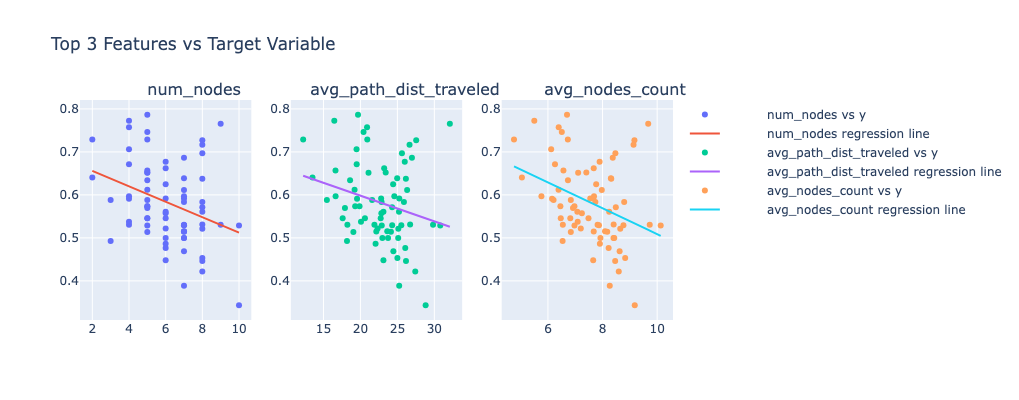

In [322]:
X, y = np.array(baseline_features), np.array(baseline_accs)
baseline_feature_str = """static_baseline_features = [
        euclid_distance, 
        path_distance, 
        num_nodes, 
        avg_path_dist_traveled, 
        avg_nodes_count, 
        avg_turns_count
    ]"""
run_evaluate_regression(X, y, feature_str=baseline_feature_str)

### Heatmap features (str counts)

In [314]:
def letter_counts(strings):
    # Create a numpy array of zeros for 26 letters (A-Z)
    counts = np.zeros(26, dtype=int)
    
    # Loop through each string in the list
    for string in strings:
        for char in string:
            if 'A' <= char <= 'Z':  # Only consider capital letters
                index = ord(char) - ord('A')  # Convert letter to its corresponding index (A=0, B=1, ..., Z=25)
                counts[index] += 1

    return counts
    
## Heatmap features
heatmap_features = []
heatmap_accs = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    str_counts = np.zeros(26)
    for string in group["paths"]:
        for char in string:
            if 'A' <= char <= 'Z':
                index = ord(char) - ord('A')  # Convert letter to its corresponding index (A=0, B=1, ..., Z=25)
                str_counts[index] += 1
    str_counts /= np.sum(str_counts) 
    str_counts *= 10
    heatmap_features.append(str_counts)
    heatmap_accs.append(group["path_mean_acc"].iloc[0])

# doing y and z makes everything horrible and crazy...
heatmap_features = np.array(heatmap_features)[:, :25]

Mean RMSE: 0.09674195634268538
Standard Deviation of RMSE: 0.01540192179988377
Linear Regression Coefficients: [ 0.0362512  -0.13616073  0.00718495 -0.22812352  0.03436439  0.28547984
 -0.18151341  0.13305842 -0.02832342  0.0579427  -0.00318819  0.05649391
 -0.16916433 -0.30234814  0.10964943 -0.01051687 -0.17333208 -0.19877163
  0.08454004 -0.10704324  0.06021376 -0.34597753  0.01527617 -0.20887678
  0.24383189]
string counts = [A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z]
Intercept: 1.00
R-squared: 0.56
(72, 25)
(72,)
(25,)
(25,)
(25,)


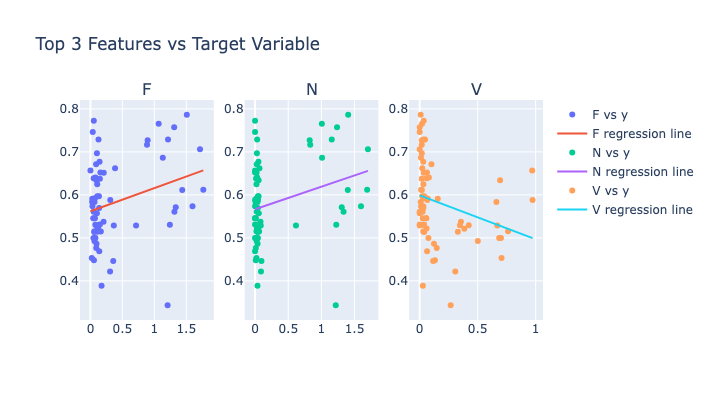

In [315]:
X, y = heatmap_features, np.array(heatmap_accs)
heatmap_feature_str = """string counts = [A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z]"""
run_evaluate_regression(X, y, feature_str=heatmap_feature_str)

### Plot all treebs
just for fun

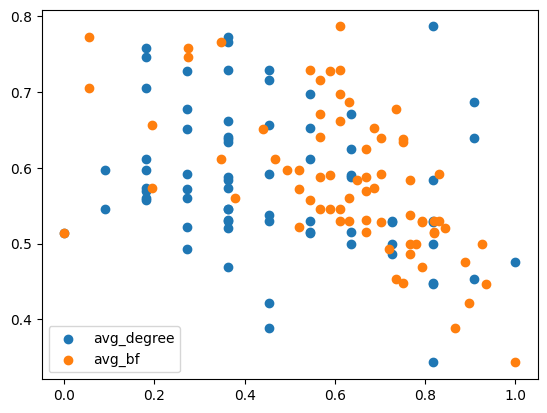

In [121]:
deg = features[:, 4]
bf = features[:, -2]

plt.scatter((deg - min(deg)) / (max(deg) - min(deg)), accs, label="avg_degree")
plt.scatter((bf - min(bf)) / (max(bf) - min(bf)), accs, label="avg_bf")

plt.legend()
plt.show()

# sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
# c=0
# for i, tree_index in enumerate(sorted_order):
#     print(f"acc: {accs[tree_index]:.2f}, avg_degree: {features[tree_index][4]}, avg_bf: {features[tree_index][-2]}")

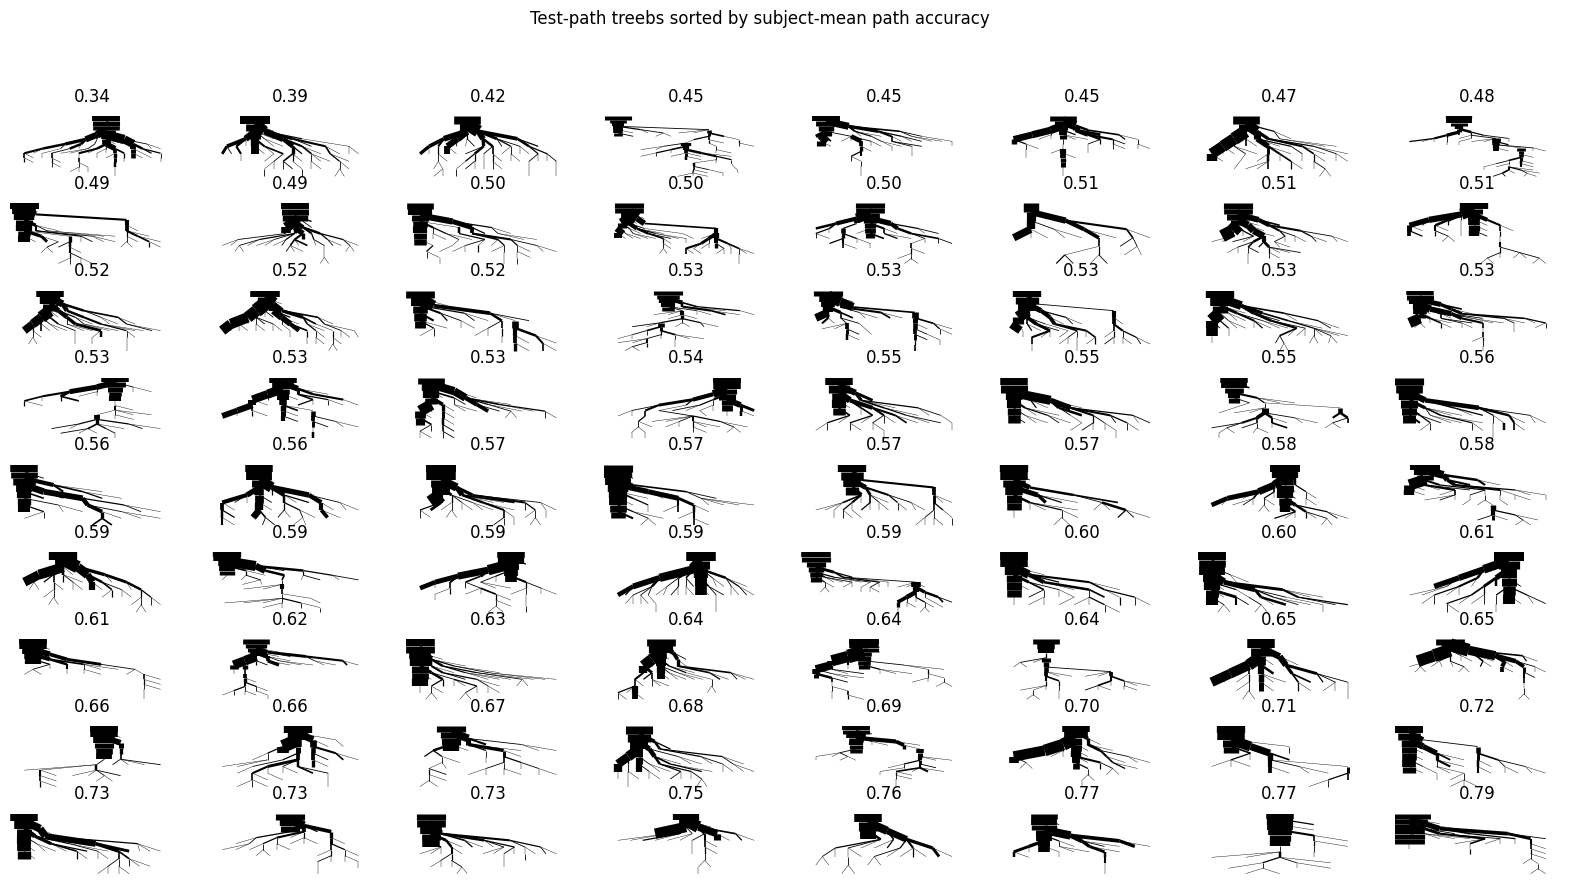

In [123]:
fig, axes = plt.subplots(9, 8, figsize=(20,10))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = treebs[tree_index]
    
    ax = axes[i // 8][i % 8]
    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * .3 for u,v in edges]

    nodes = G.nodes()
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]

    # nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=ax) # font_weight="bold",

    ax.axis("off")
    ax.set_title(f"{accs[tree_index]:.2f}")
    
    
    # if c>10:
    #     break
    # c += 1

fig.suptitle("Test-path treebs sorted by subject-mean path accuracy")
fig.savefig("figures/test_treebs_by_acc.png")

plt.show()


# compare to baseline
#   of min path distance!


# compute only treeb of get it right? 
# try treeb of people who get it wrong??

Treeb 39, acc=0.34


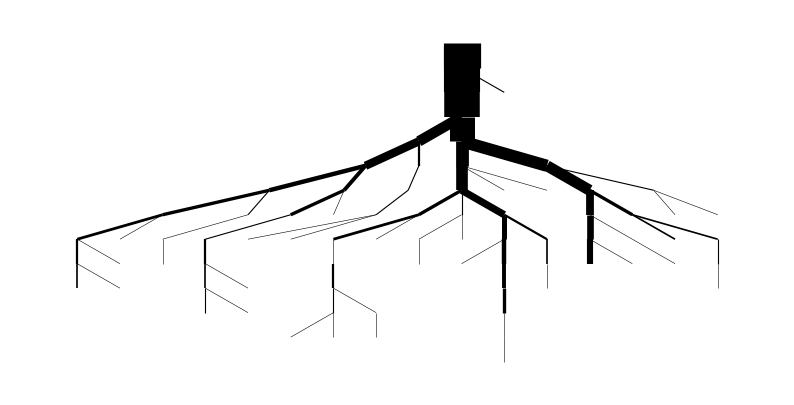

Treeb 45, acc=0.39


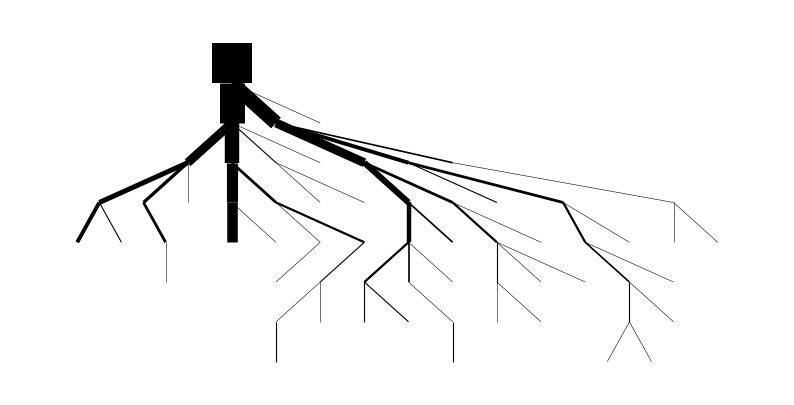

Treeb 47, acc=0.42


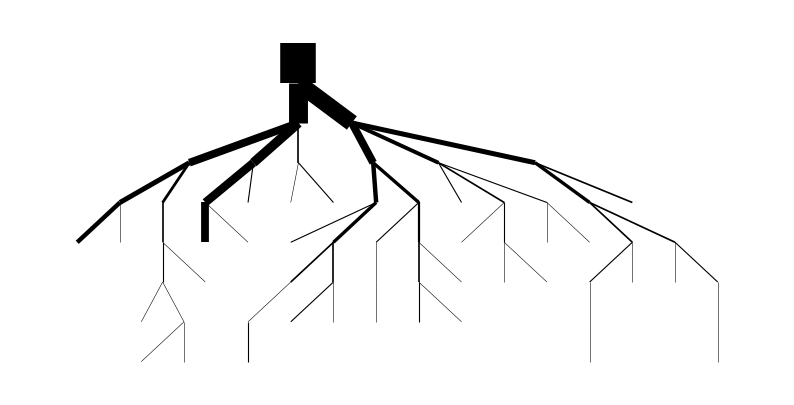

Treeb 40, acc=0.45


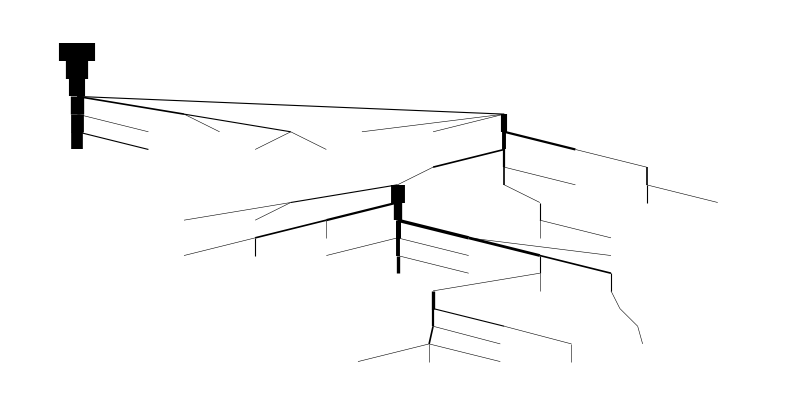

Treeb 21, acc=0.45


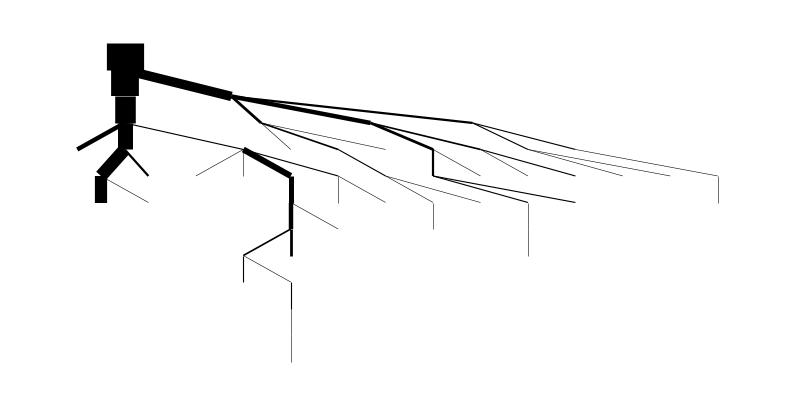

Treeb 65, acc=0.45


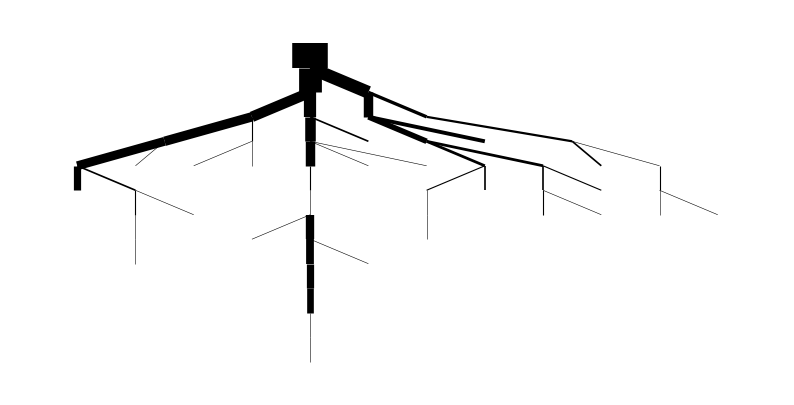

Treeb 13, acc=0.47


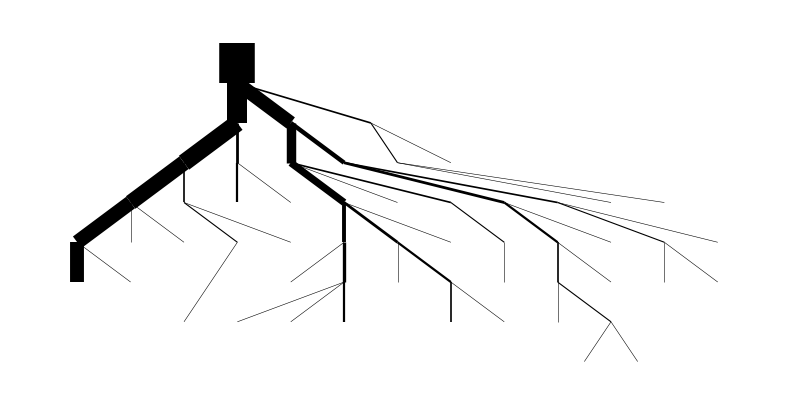

Treeb 56, acc=0.48


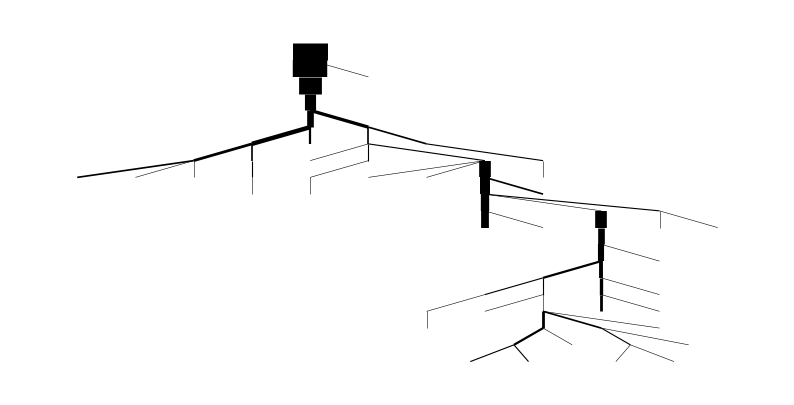

Treeb 5, acc=0.49


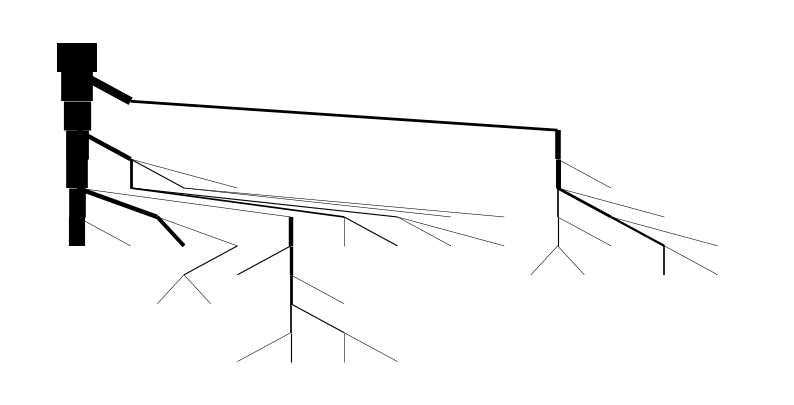

Treeb 55, acc=0.49


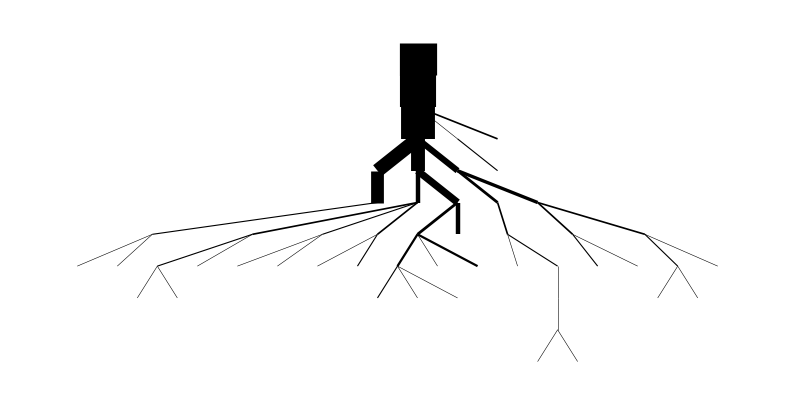

Treeb 29, acc=0.50


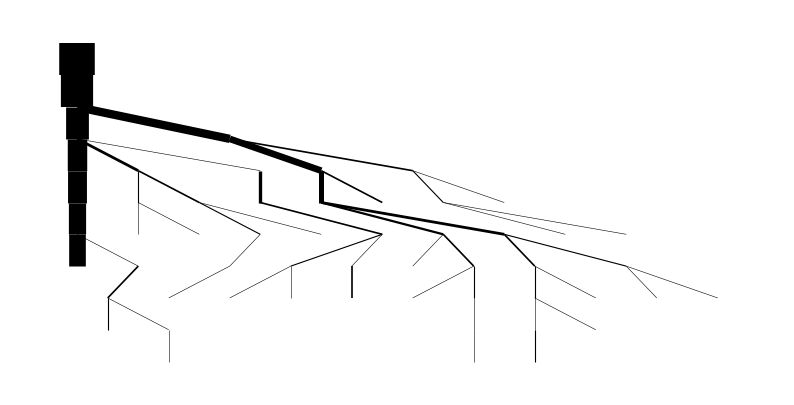

Treeb 64, acc=0.50


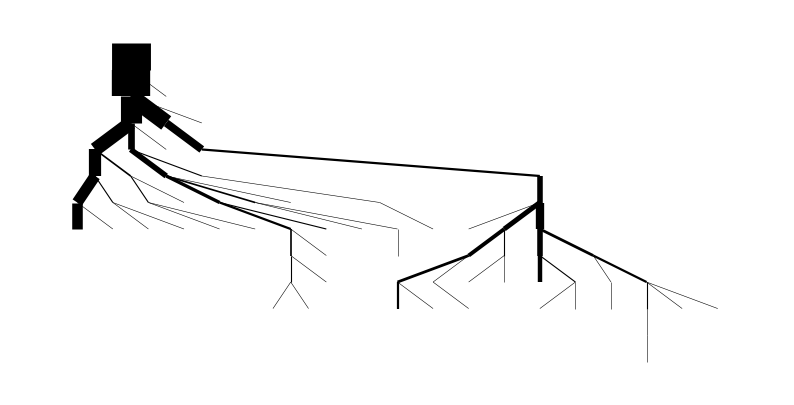

Treeb 67, acc=0.50


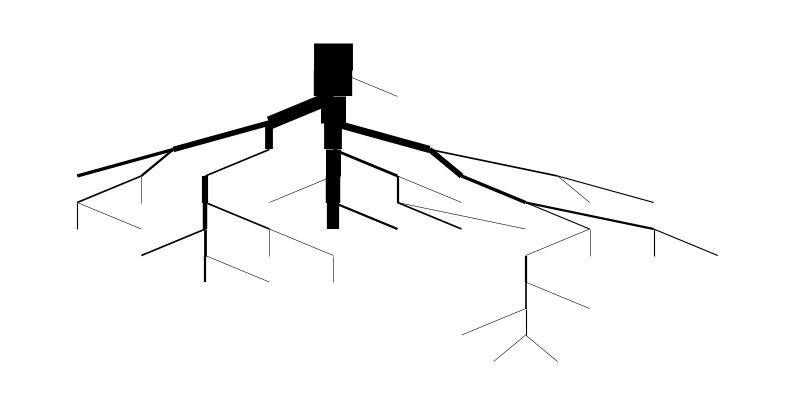

Treeb 10, acc=0.51


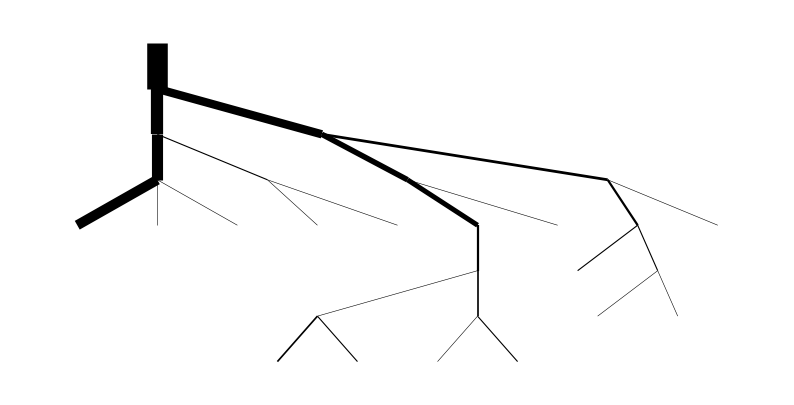

Treeb 31, acc=0.51


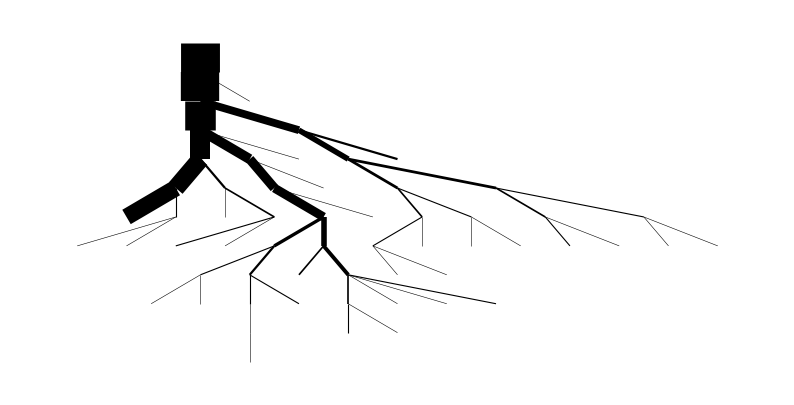

Treeb 16, acc=0.51


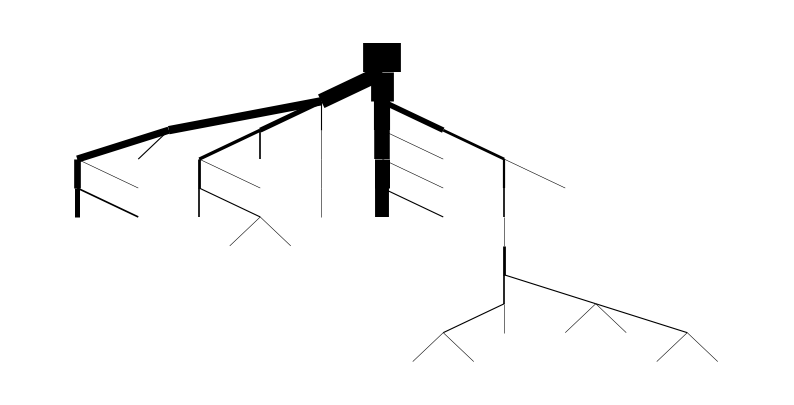

Treeb 66, acc=0.52


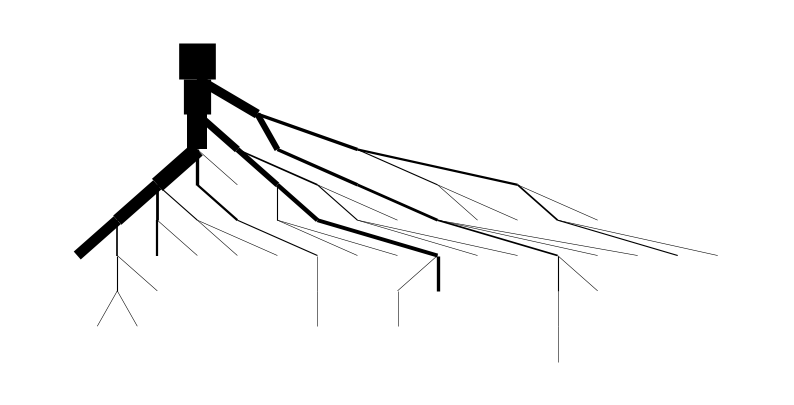

Treeb 15, acc=0.52


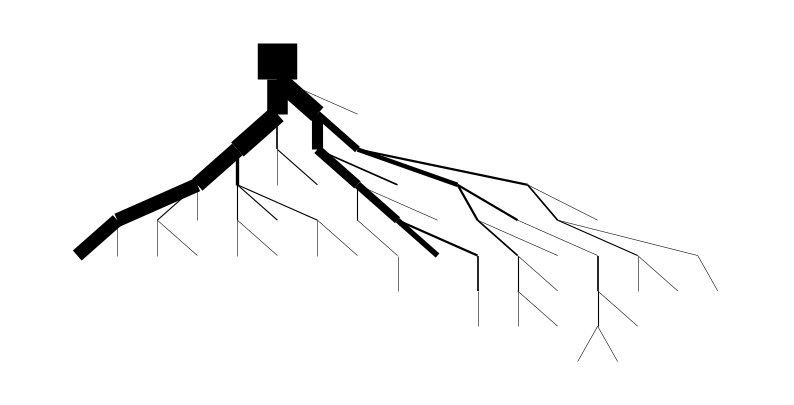

Treeb 57, acc=0.52


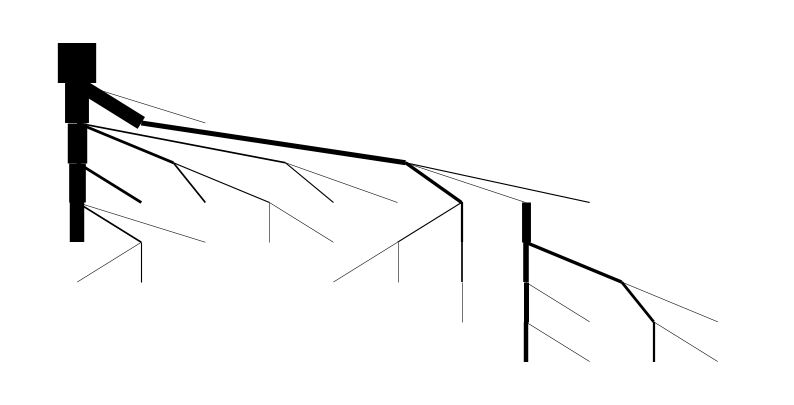

Treeb 41, acc=0.53


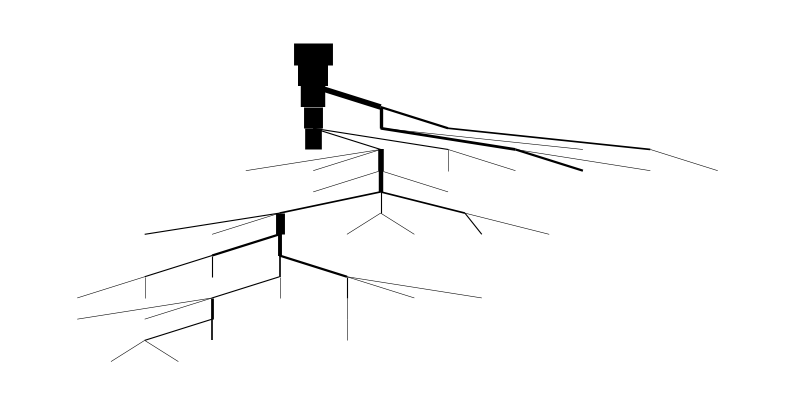

Treeb 68, acc=0.53


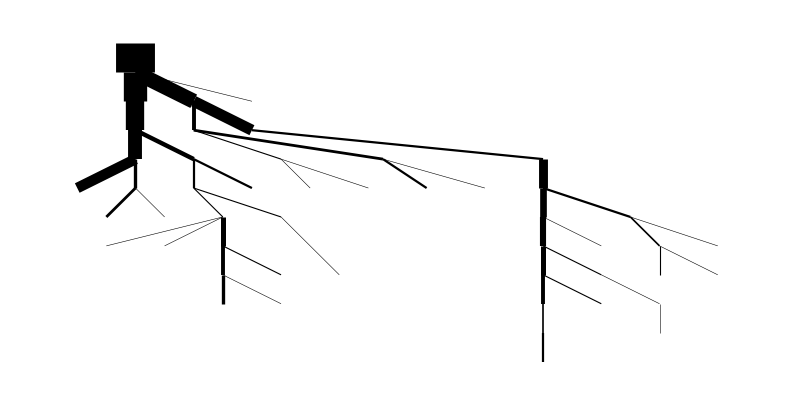

Treeb 7, acc=0.53


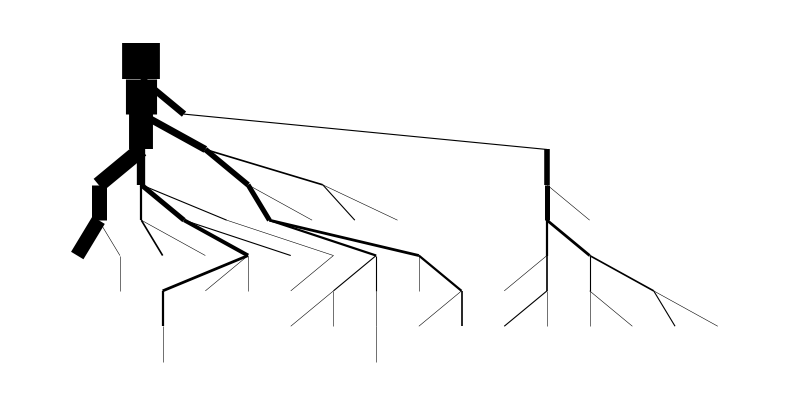

Treeb 23, acc=0.53


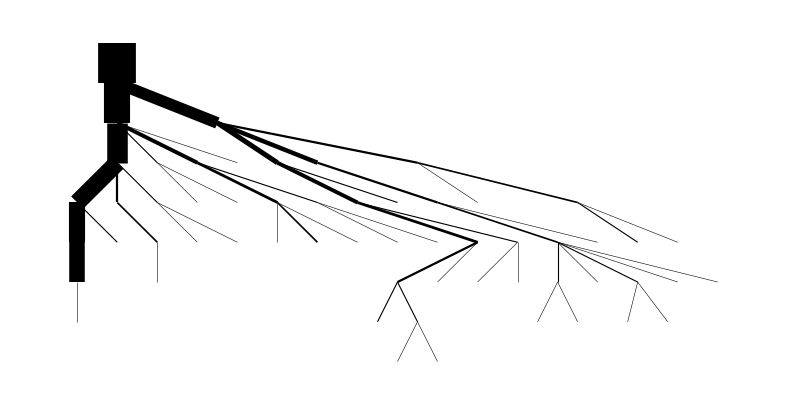

Treeb 1, acc=0.53


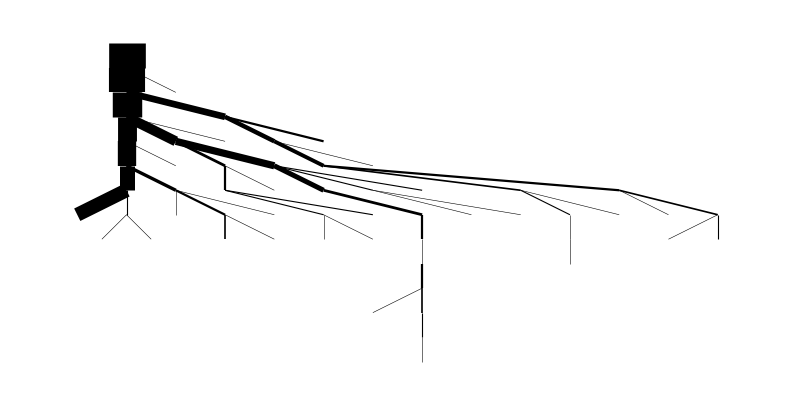

Treeb 9, acc=0.53


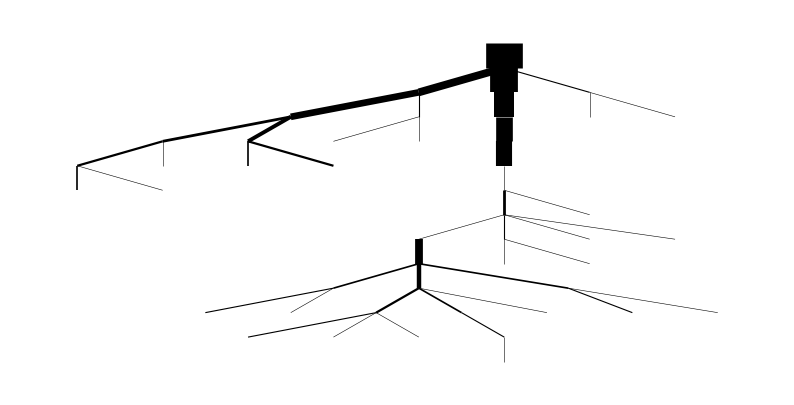

Treeb 37, acc=0.53


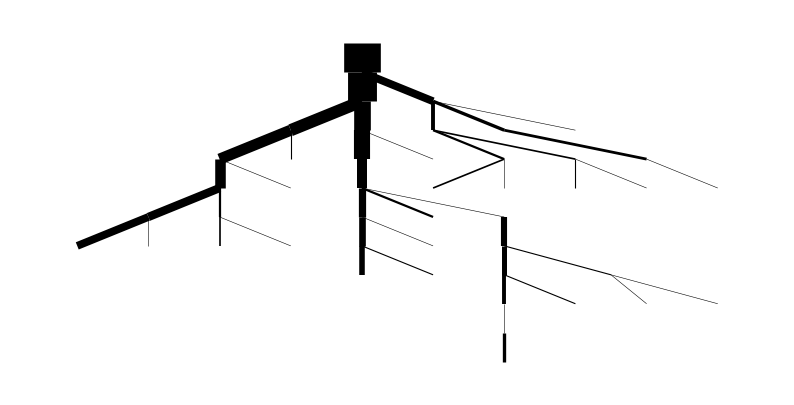

Treeb 43, acc=0.53


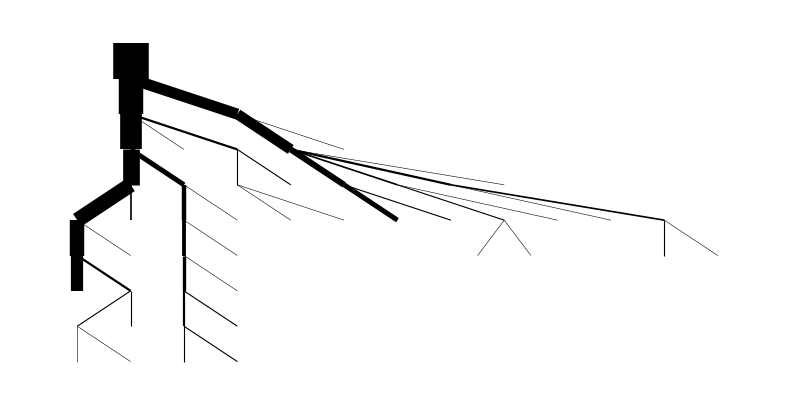

Treeb 62, acc=0.54


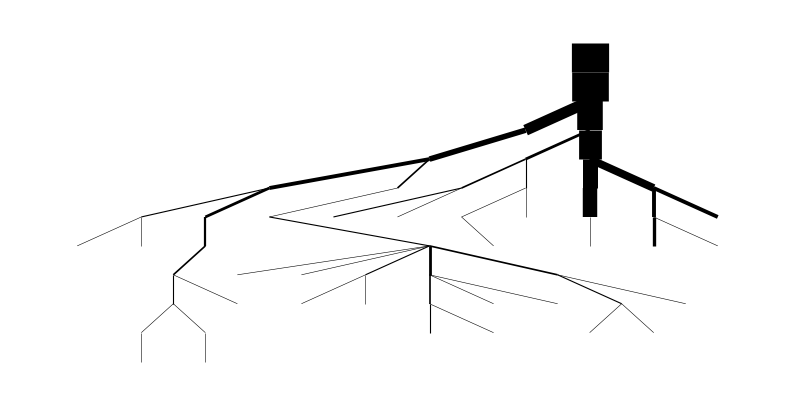

Treeb 0, acc=0.55


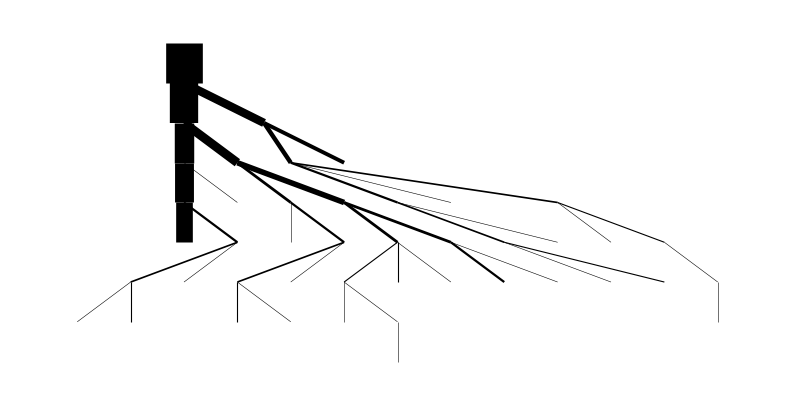

Treeb 48, acc=0.55


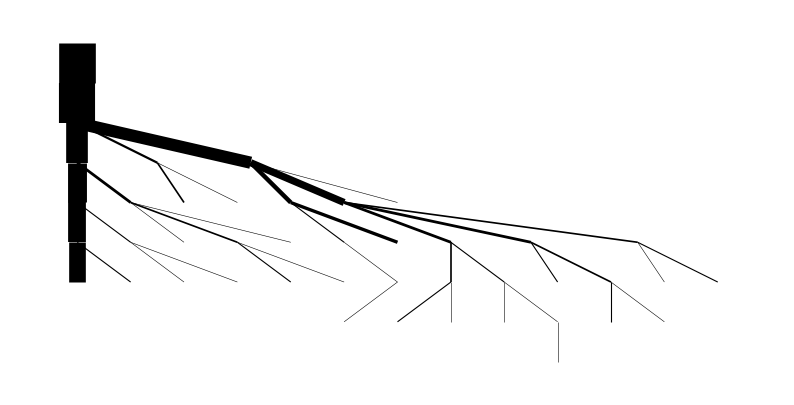

Treeb 61, acc=0.55


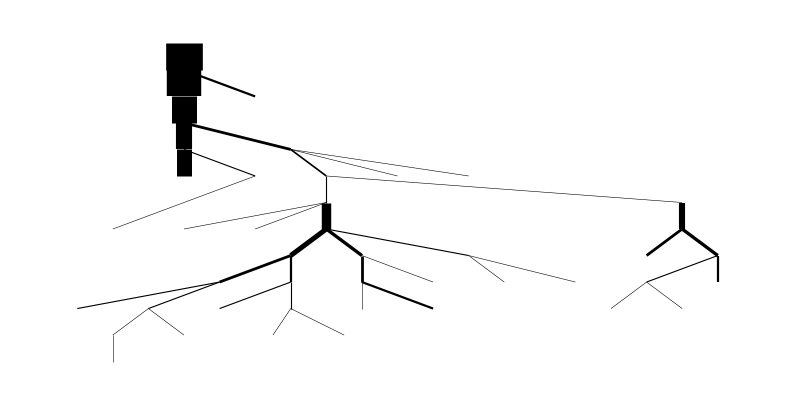

Treeb 51, acc=0.56


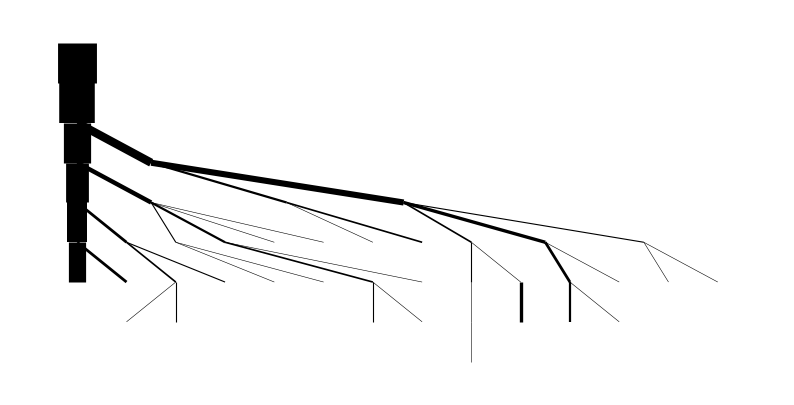

Treeb 35, acc=0.56


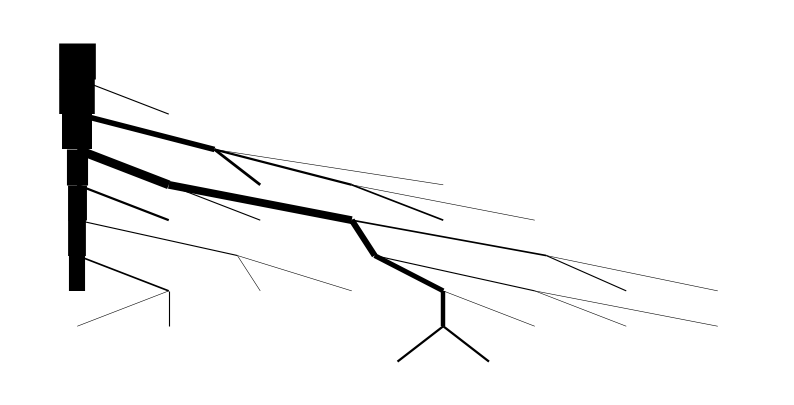

Treeb 59, acc=0.56


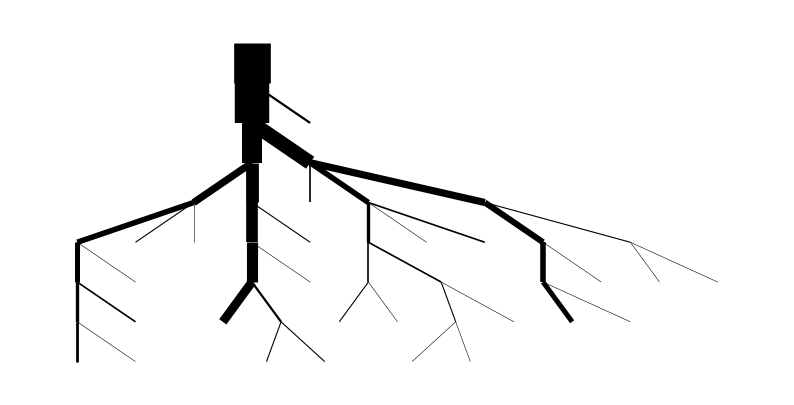

Treeb 8, acc=0.57


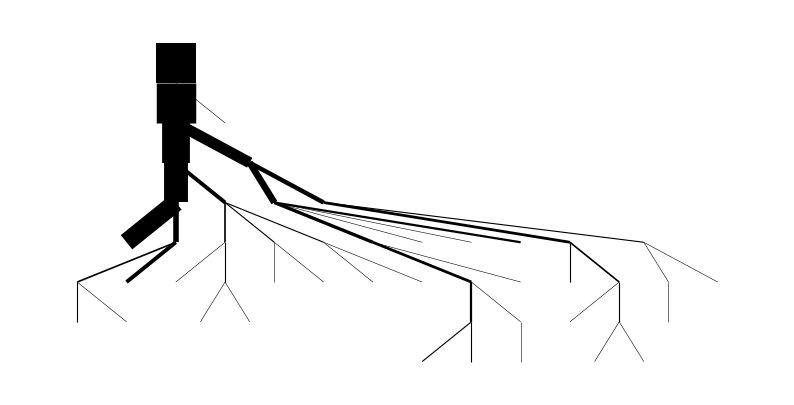

Treeb 32, acc=0.57


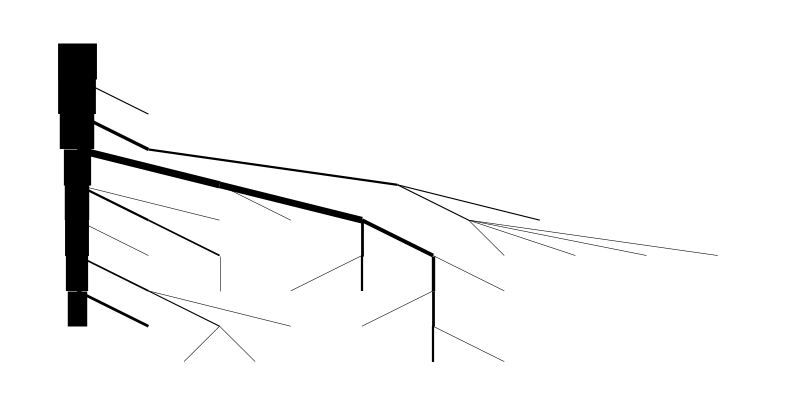

Treeb 25, acc=0.57


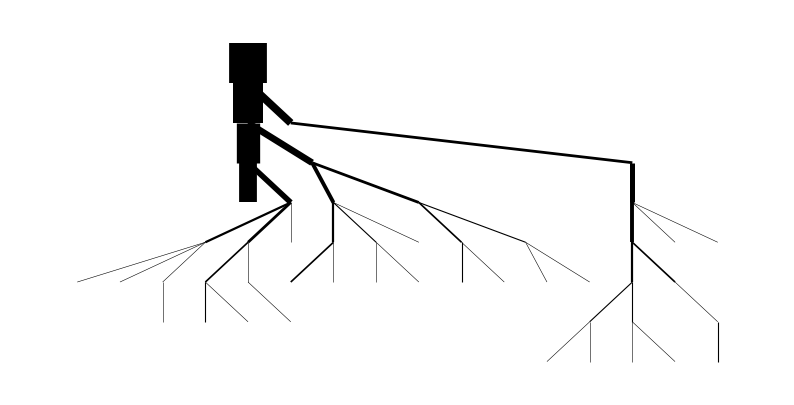

Treeb 34, acc=0.57


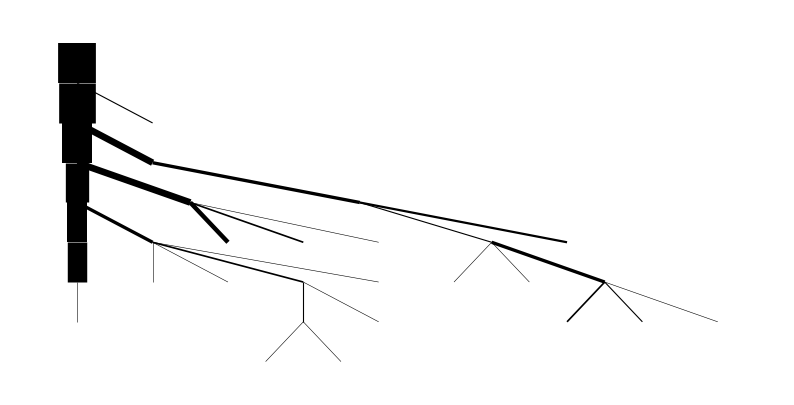

Treeb 26, acc=0.58


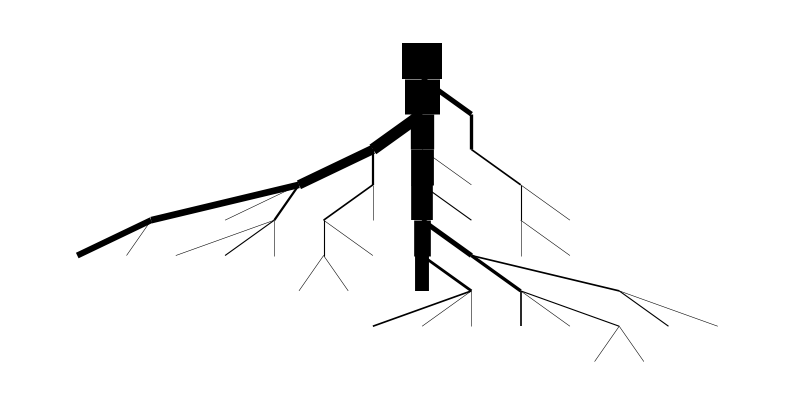

Treeb 69, acc=0.58


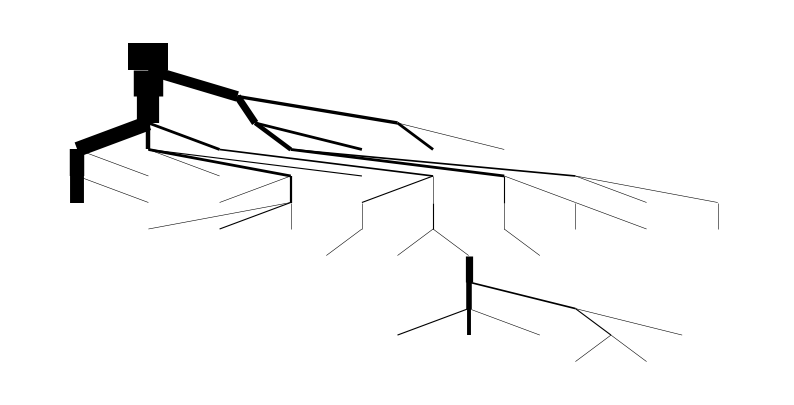

Treeb 42, acc=0.59


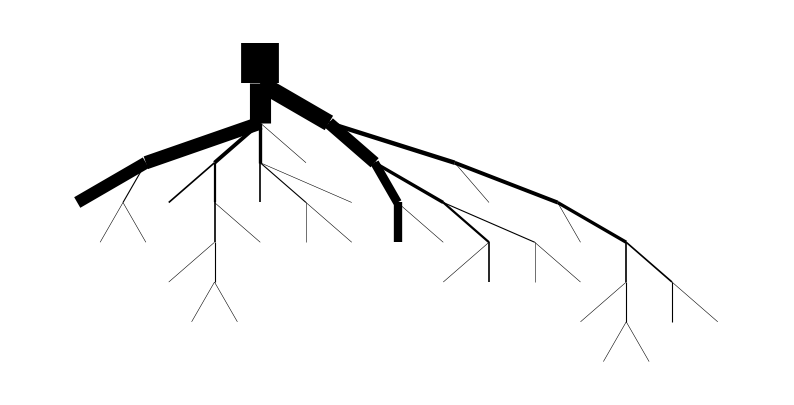

Treeb 70, acc=0.59


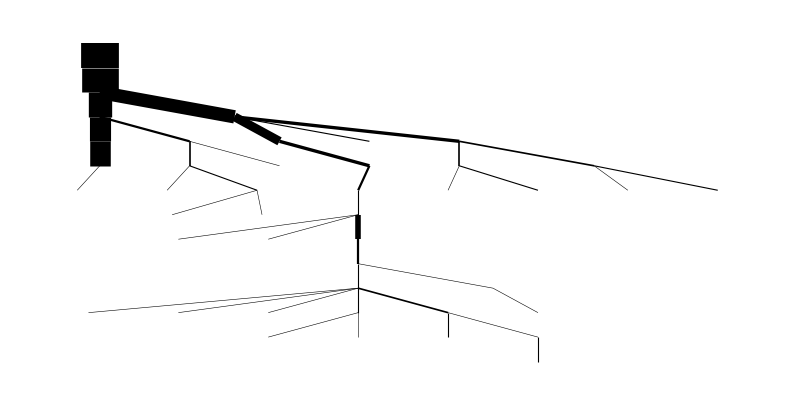

Treeb 58, acc=0.59


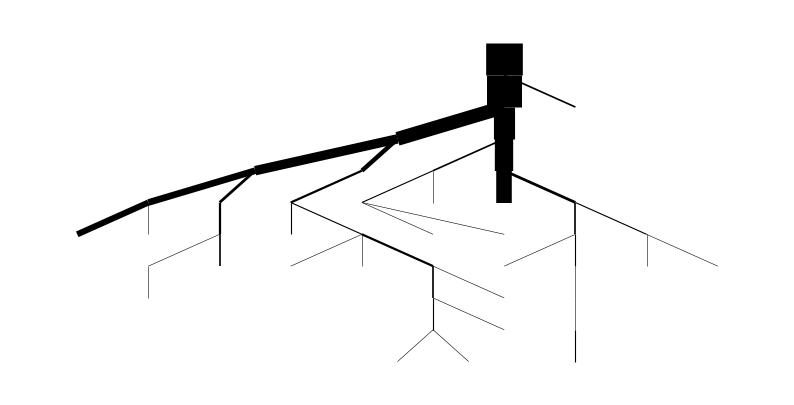

Treeb 18, acc=0.59


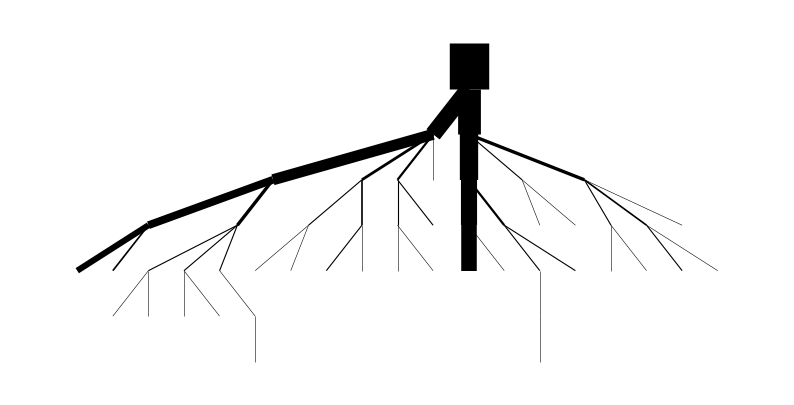

Treeb 50, acc=0.59


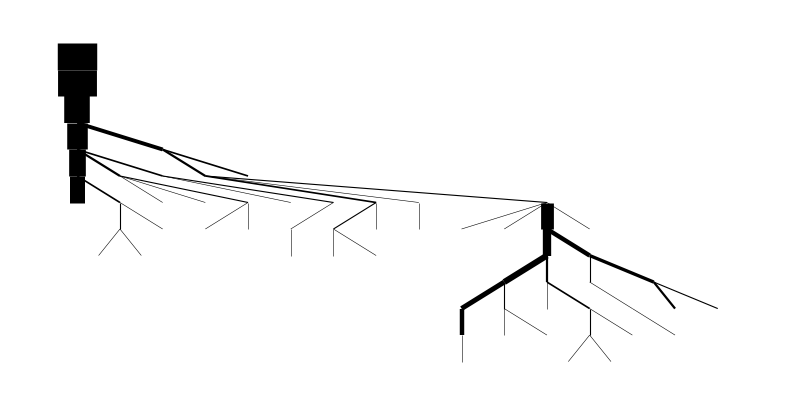

Treeb 17, acc=0.60


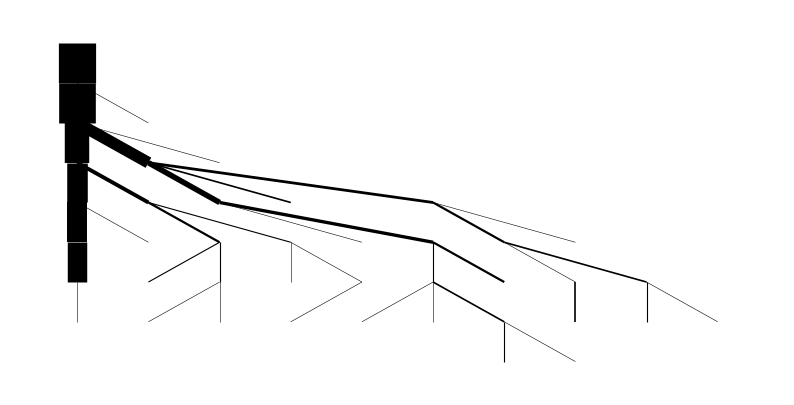

Treeb 53, acc=0.60


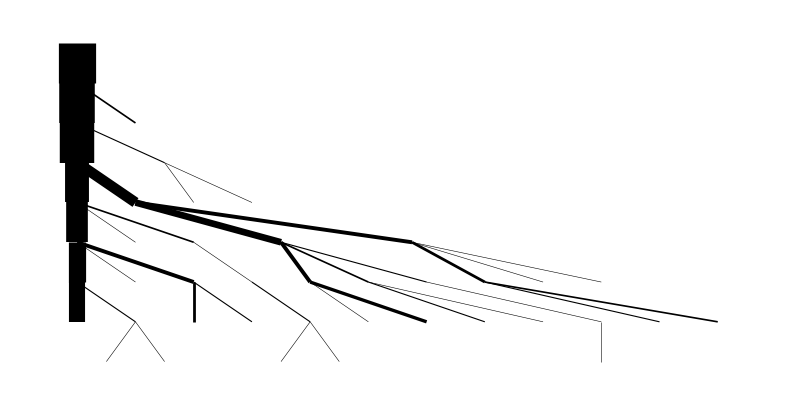

Treeb 38, acc=0.61


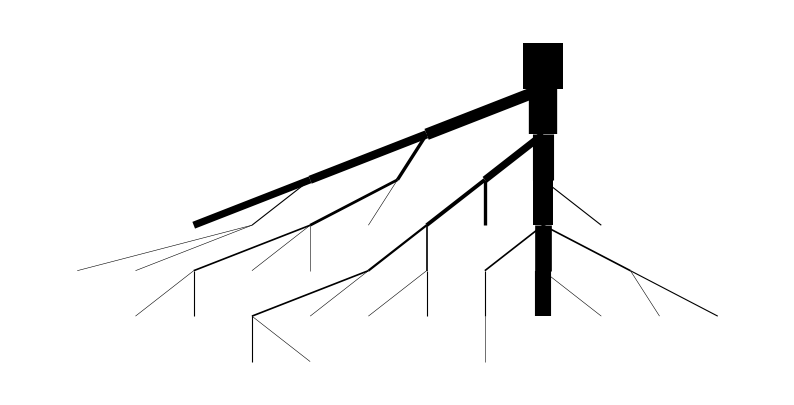

Treeb 33, acc=0.61


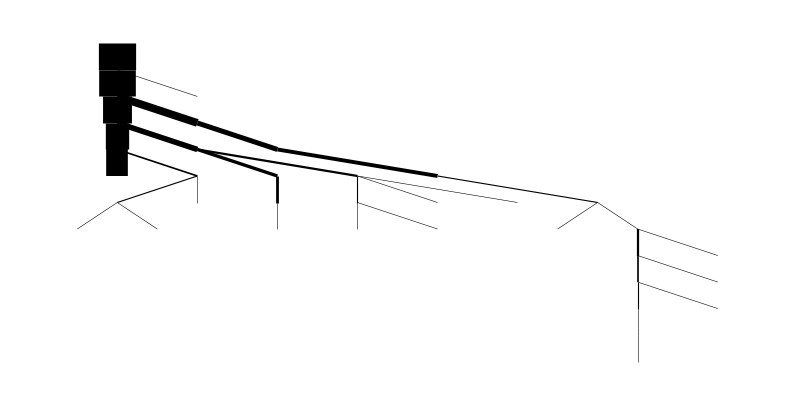

Treeb 6, acc=0.62


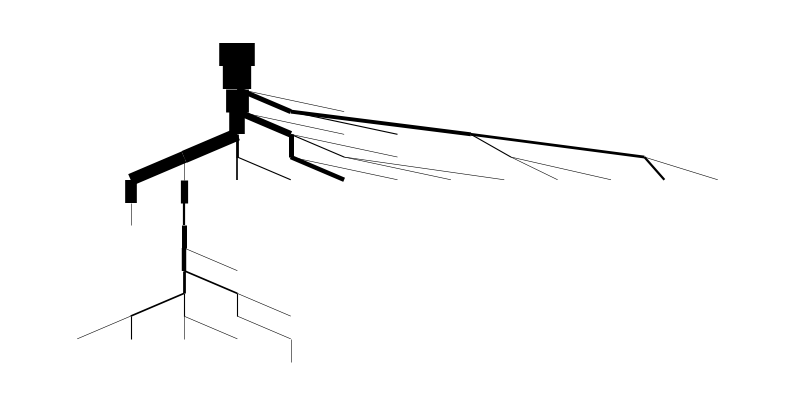

Treeb 63, acc=0.63


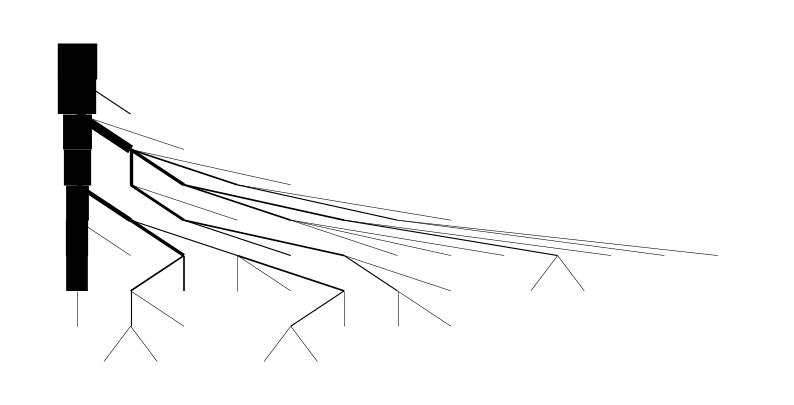

Treeb 28, acc=0.64


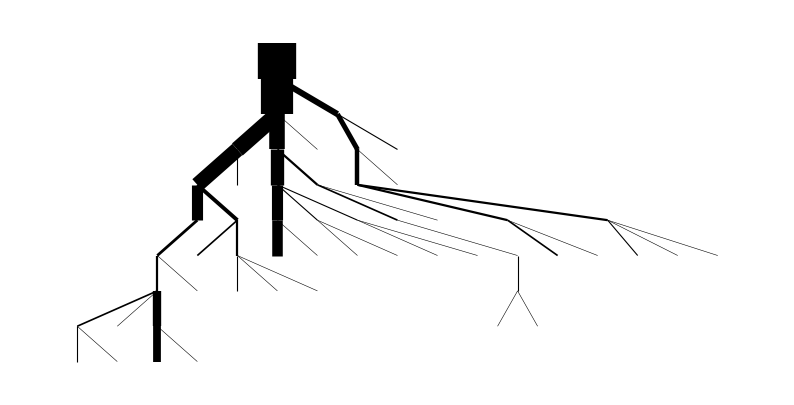

Treeb 49, acc=0.64


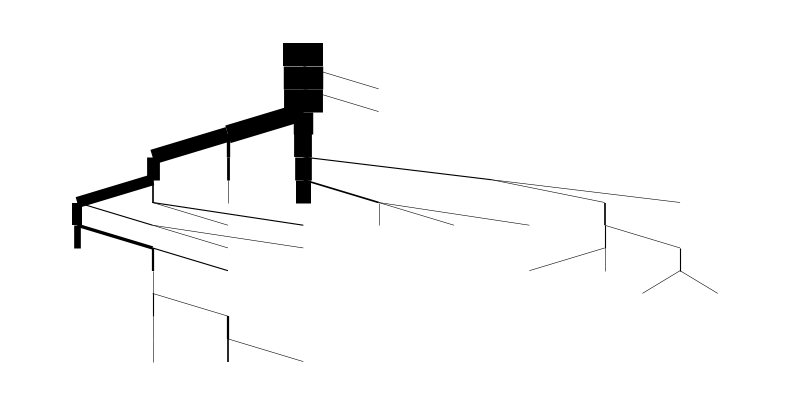

Treeb 24, acc=0.64


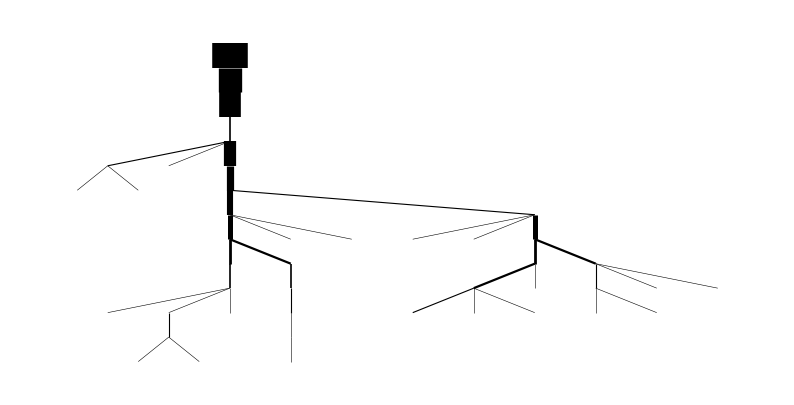

Treeb 12, acc=0.65


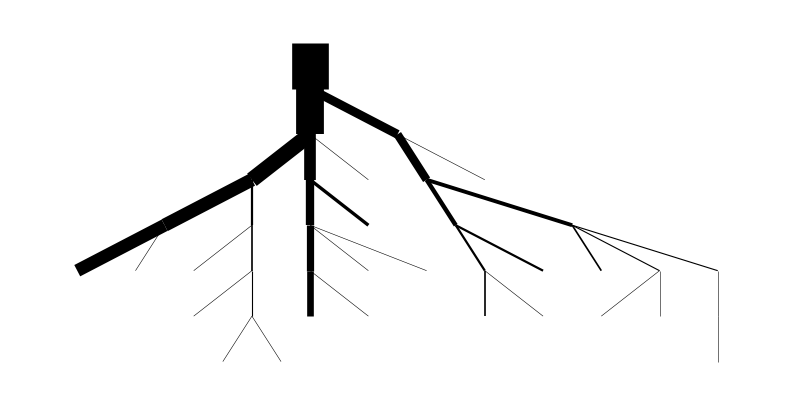

Treeb 46, acc=0.65


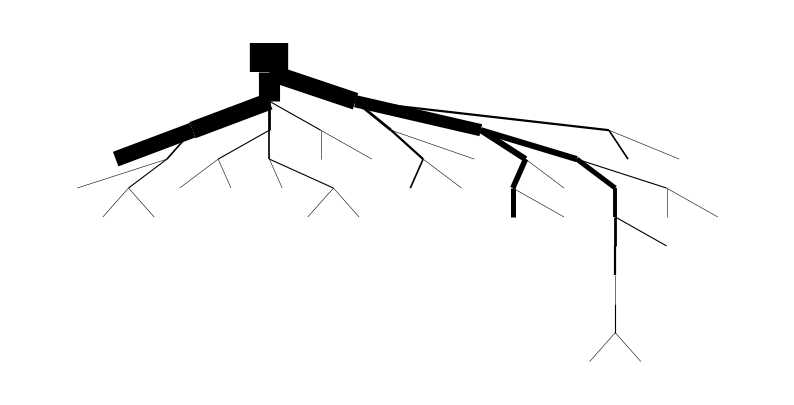

Treeb 71, acc=0.66


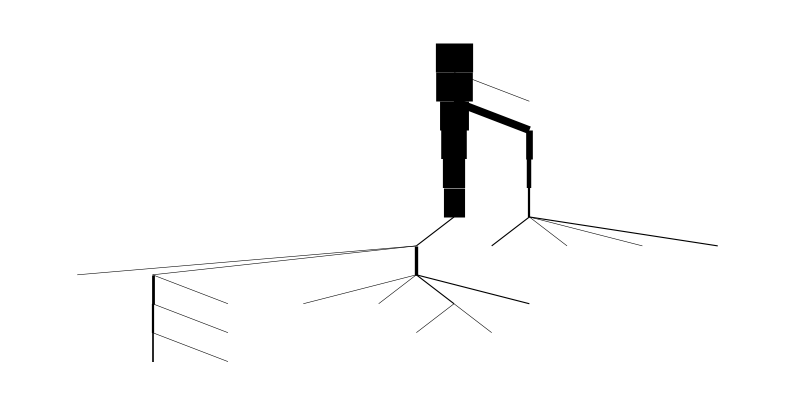

Treeb 14, acc=0.66


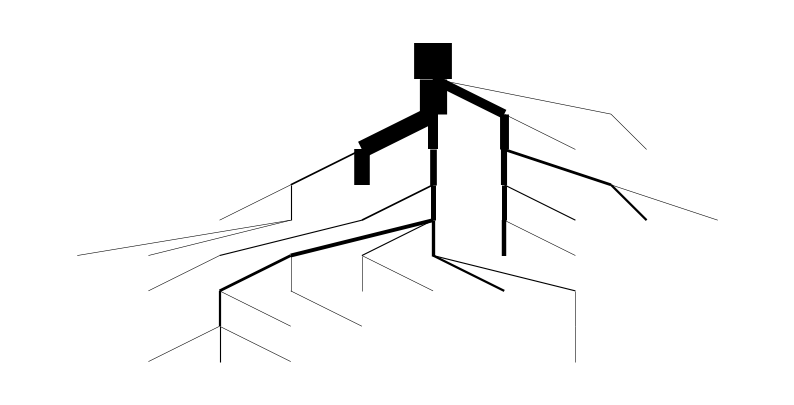

Treeb 22, acc=0.67


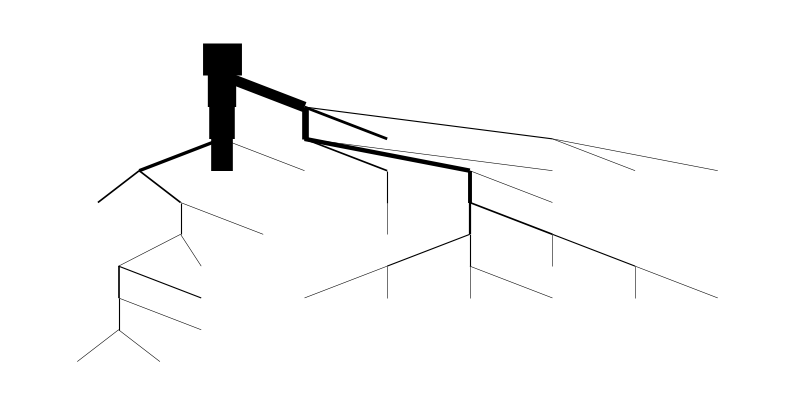

Treeb 30, acc=0.68


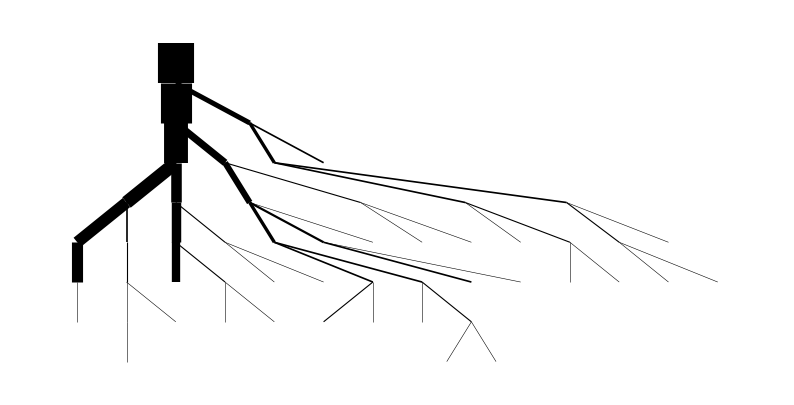

Treeb 60, acc=0.69


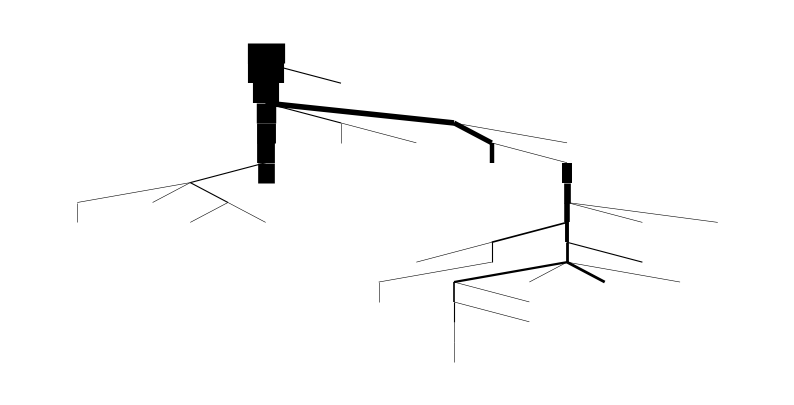

Treeb 4, acc=0.70


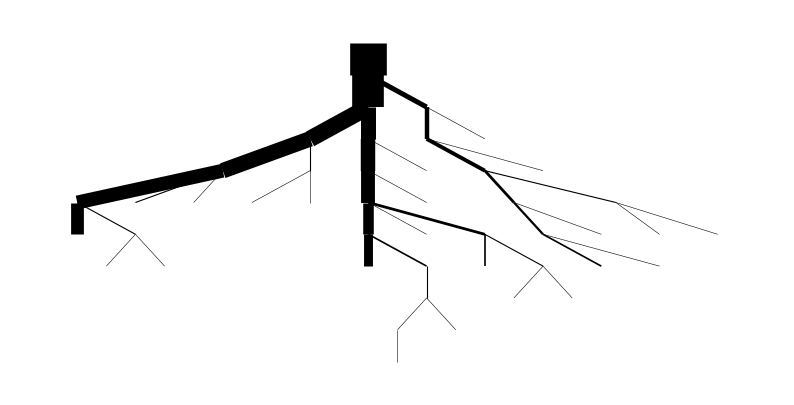

Treeb 36, acc=0.71


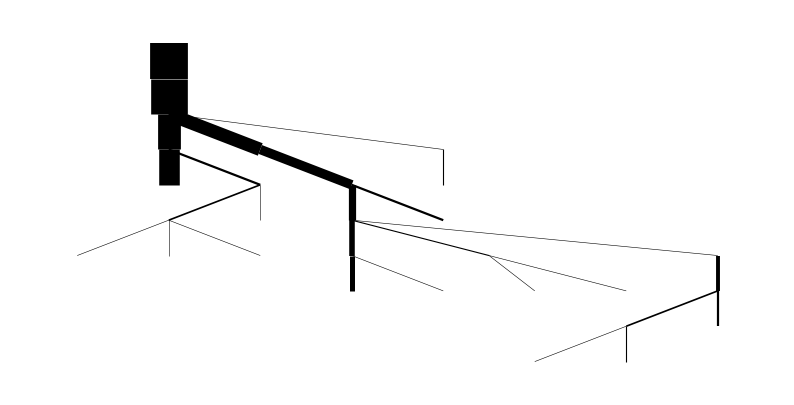

Treeb 3, acc=0.72


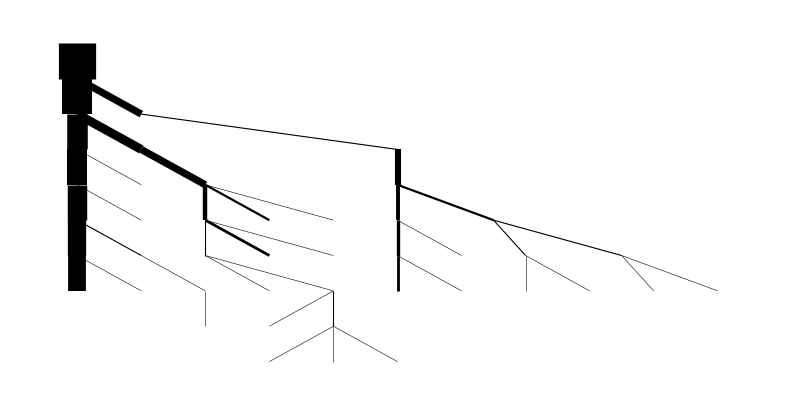

Treeb 27, acc=0.73


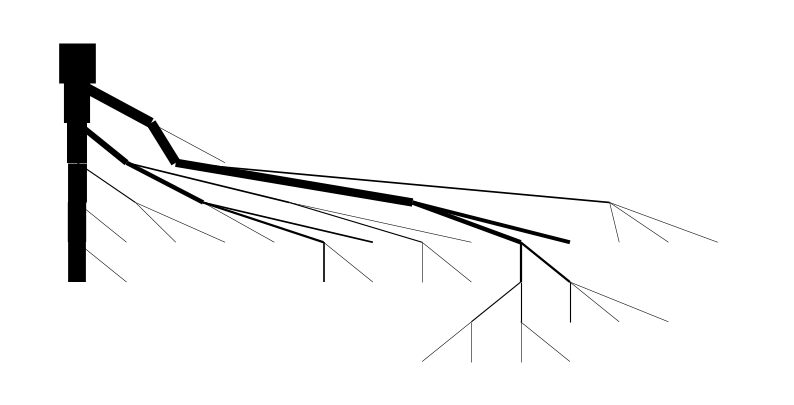

Treeb 2, acc=0.73


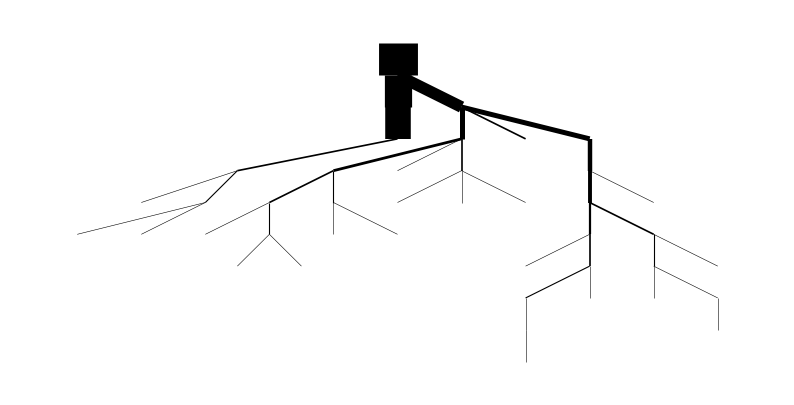

Treeb 19, acc=0.73


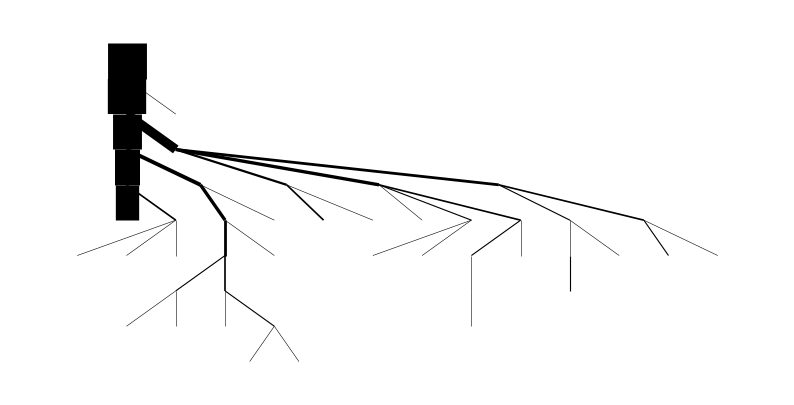

Treeb 20, acc=0.75


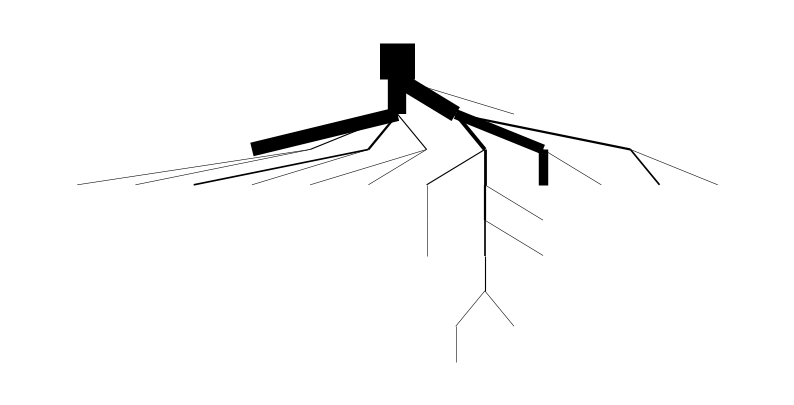

Treeb 44, acc=0.76


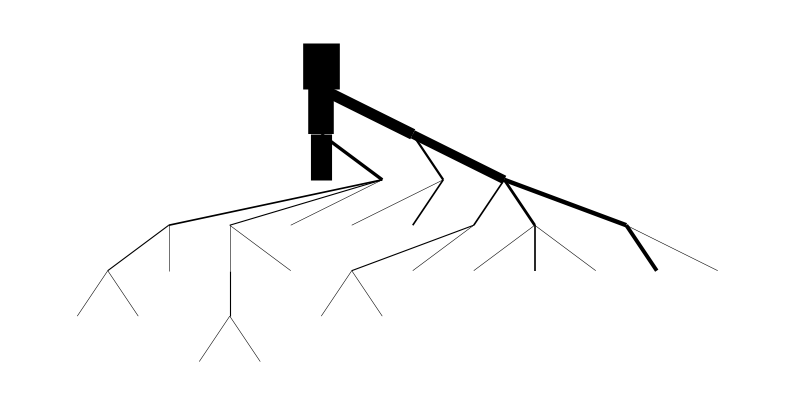

Treeb 52, acc=0.77


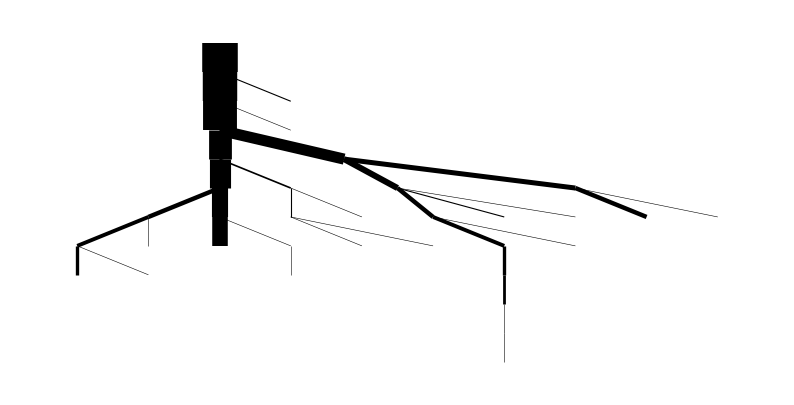

Treeb 54, acc=0.77


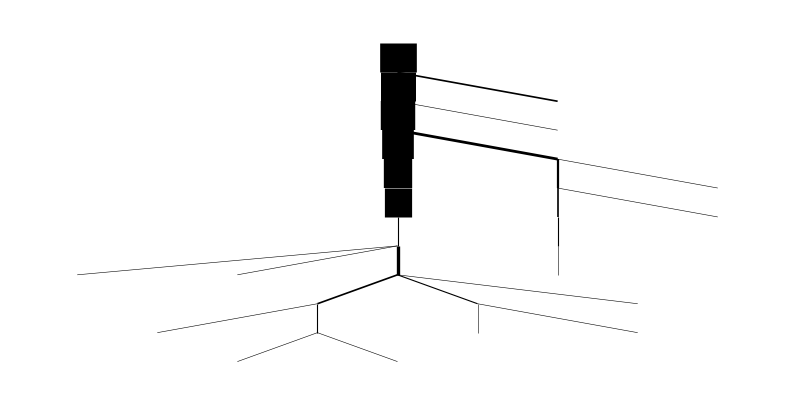

Treeb 11, acc=0.79


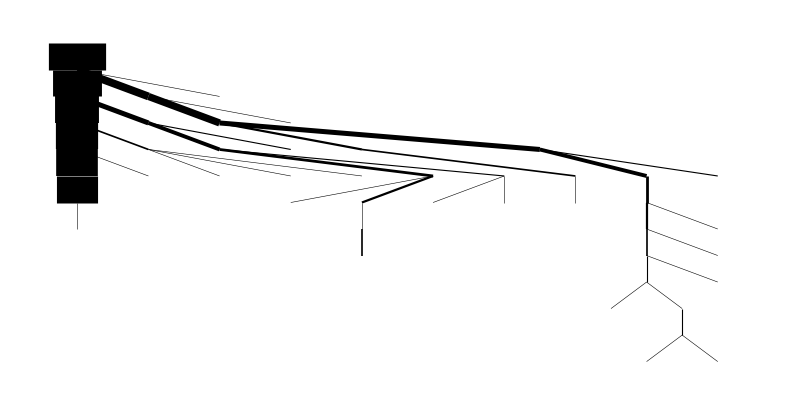

In [88]:
def plot_treeb(G):
    fig = plt.figure(figsize=(10,5))
    this_ax = plt.gca()

    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * .4 for u,v in edges]

    nodes = G.nodes()
    # for n in nodes:
    #     print(n, G.nodes[n])
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
    # print(n_colors)
    # print ((q-1) // 2, (q-1) % 2)
    nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=this_ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=this_ax) # font_weight="bold",

    this_ax.axis("off")
    plt.show()

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
# c=0
for i in sorted_order:
    print(f"Treeb {i}, acc={accs[i]:.2f}")
    plot_treeb(treebs[i])
    # if c>5:
    #     break
    # c += 1